# Linguistic Feature Ablation Study: Prompt Sensitivity in LLMs

This notebook implements a controlled ablation experiment to identify
which specific linguistic features drive prompt sensitivity in large
language models. We test four conditions (lexical substitution,
syntactic restructuring, voice alternation, formality shift) across
five benchmarks and three models.

**Name** : Anjana Manoj

**Student ID**: s223483467

**Unit**: SIT330 - Natural Language Processing


## 1. Install Dependencies
Installing all required libraries.

In [2]:
!pip install openai bert-score datasets tqdm pandas sacrebleu huggingface_hub transformers torch -q

## 2. Configuration
Setting up API keys and defining the main experiment variables.
4 tasks, 4 linguistic conditions, 3 models, 50 instances each.

In [4]:
import os

OPENAI_API_KEY = "api_key"
HF_API_KEY = "api_key"

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
os.environ["HF_API_KEY"] = HF_API_KEY
os.environ["HF_TOKEN"] = HF_API_KEY

TASKS = ["trivia_qa", "hellaswag", "sst2", "boolq", "mmlu"]
CONDITIONS = ["lexical", "syntactic", "voice", "formality"]
MODELS = ["gpt-3.5-turbo", "llama-3-8b", "gemma-3-1b"]
N_INSTANCES = 50

## 3. Load Datasets
Loading 50 random instances from each of the five benchmarks.
TriviaQA covers factual recall, HellaSwag covers commonsense
reasoning, SST-2 covers sentiment classification, BoolQ adds
yes/no reading comprehension, and MMLU covers professional and
academic knowledge across 57 subjects. Random seed fixed at 42
for reproducibility.

In [5]:
from datasets import load_dataset
import random

random.seed(42)

def load_instances():
    instances = {}

    # TriviaQA
    tqa = load_dataset("mandarjoshi/trivia_qa", "rc.nocontext", split="validation")
    idx = random.sample(range(len(tqa)), N_INSTANCES)
    instances["trivia_qa"] = [
        {
            "id": i,
            "question": tqa[i]["question"],
            "answer": tqa[i]["answer"]["value"],
            "task": "trivia_qa"
        }
        for i in idx
    ]

    # HellaSwag
    hswag = load_dataset("Rowan/hellaswag", split="validation")
    idx = random.sample(range(len(hswag)), N_INSTANCES)
    instances["hellaswag"] = [
        {
            "id": i,
            "question": hswag[i]["ctx"],
            "endings": hswag[i]["endings"],
            "answer": hswag[i]["label"],
            "task": "hellaswag"
        }
        for i in idx
    ]

    # SST-2
    sst = load_dataset("stanfordnlp/sst2", split="validation")
    idx = random.sample(range(len(sst)), N_INSTANCES)
    instances["sst2"] = [
        {
            "id": i,
            "question": sst[i]["sentence"],
            "answer": str(sst[i]["label"]),
            "task": "sst2"
        }
        for i in idx
    ]

    # BoolQ
    boolq = load_dataset("google/boolq", split="validation")
    idx = random.sample(range(len(boolq)), N_INSTANCES)
    instances["boolq"] = [
        {
            "id": i,
            "question": boolq[i]["question"],
            "passage": boolq[i]["passage"][:300],
            "answer": "1" if boolq[i]["answer"] else "0",
            "task": "boolq"
        }
        for i in idx
    ]

    # MMLU
    mmlu = load_dataset("cais/mmlu", "all", split="validation")
    idx = random.sample(range(len(mmlu)), N_INSTANCES)
    instances["mmlu"] = [
        {
            "id": i,
            "question": mmlu[i]["question"],
            "choices": mmlu[i]["choices"],
            "answer": str(mmlu[i]["answer"]),
            "task": "mmlu"
        }
        for i in idx
    ]

    return instances

instances = load_instances()
print({k: len(v) for k, v in instances.items()})

README.md:   0%|          | 0.00/26.7k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

rc.nocontext/validation-00000-of-00001.p(…):   0%|          | 0.00/7.34M [00:00<?, ?B/s]

rc.nocontext/test-00000-of-00001.parquet:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/14042 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1531 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating auxiliary_train split:   0%|          | 0/99842 [00:00<?, ? examples/s]

{'trivia_qa': 50, 'hellaswag': 50, 'sst2': 50, 'boolq': 50, 'mmlu': 50}


## 4. Paraphrase Generation
Generates controlled paraphrases that change exactly one linguistic
dimension at a time. Each condition has a separate system prompt
that explicitly prevents changes to the other three dimensions.
Temperature set to 0 for deterministic outputs. Includes a regex
fallback parser to handle cases where GPT-3.5 returns malformed JSON.

In [12]:
from openai import OpenAI
import json, time, re

client = OpenAI(api_key=OPENAI_API_KEY)

CONDITION_PROMPTS = {
    "lexical": """You are helping with a controlled linguistics experiment.
Rewrite the question by swapping content words with synonyms ONLY.
Rules:
- Only change nouns, verbs, adjectives with synonyms
- Keep sentence structure identical
- Keep voice identical (active stays active)
- Keep formality level identical
- The correct answer must not change
Return only JSON: {"paraphrase": "...", "changes": "list words swapped"}""",

    "syntactic": """You are helping with a controlled linguistics experiment.
Rewrite the question by changing clause structure ONLY.
Rules:
- Only change syntactic structure (e.g. simple to embedded clause or inverted construction)
- Do not swap any words for synonyms
- Do not change voice
- Do not change formality
- The correct answer must not change
Return only JSON: {"paraphrase": "...", "changes": "describe structural change"}""",

    "voice": """You are helping with a controlled linguistics experiment.
Rewrite the question by changing grammatical voice ONLY (active to passive or passive to active).
Rules:
- Only change voice
- Do not swap vocabulary
- Do not change clause structure beyond what voice conversion requires
- Do not change formality
- The correct answer must not change
Return only JSON: {"paraphrase": "...", "changes": "active to passive or passive to active"}""",

    "formality": """You are helping with a controlled linguistics experiment.
Rewrite the question by shifting register ONLY (formal to casual or casual to formal).
Rules:
- Only change formality level
- Do not swap core vocabulary with synonyms
- Do not change syntactic structure
- Do not change voice
- The correct answer must not change
Return only JSON: {"paraphrase": "...", "changes": "describe register shift"}"""
}

def generate_paraphrase(question, condition, retries=3):
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[
                    {"role": "system", "content": CONDITION_PROMPTS[condition]},
                    {"role": "user", "content": f"Question: {question}"}
                ],
                temperature=0,
                max_tokens=200
            )
            text = resp.choices[0].message.content.strip()

            # clean up common formatting issues
            text = text.replace("```json", "").replace("```", "").strip()

            # try direct parse first
            try:
                parsed = json.loads(text)
                return parsed.get("paraphrase", ""), parsed.get("changes", "")
            except json.JSONDecodeError:
                pass

            # if that fails, extract with regex
            para_match = re.search(r'"paraphrase"\s*:\s*"([^"]*)"', text)
            changes_match = re.search(r'"changes"\s*:\s*"([^"]*)"', text)

            if para_match:
                paraphrase = para_match.group(1)
                changes = changes_match.group(1) if changes_match else ""
                return paraphrase, changes

            print(f"  Could not parse response: {text[:100]}")

        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return "", ""

## 5. Back-Translation Verification
Checks that each paraphrase preserves the original meaning by
translating it to French and back to English using GPT-3.5.
Paraphrases where the meaning shifted too much are filtered out
before inference, preventing artificially inflated inconsistency rates.

In [13]:
def back_translate(text, retries=3):
    """Translate to French then back to English using GPT-3.5."""
    for attempt in range(retries):
        try:
            r1 = client.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user",
                           "content": f"Translate to French, return only the translation:\n{text}"}],
                temperature=0, max_tokens=150
            )
            french = r1.choices[0].message.content.strip()
            time.sleep(0.3)
            r2 = client.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user",
                           "content": f"Translate to English, return only the translation:\n{french}"}],
                temperature=0, max_tokens=150
            )
            return r2.choices[0].message.content.strip()
        except Exception as e:
            print(f"  Back-translation attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return text

## 6. Generate Full Paraphrase Dataset
Runs paraphrase generation across all tasks, instances, and
conditions. Filters out low quality pairs using BERTScore
(threshold 0.85) and back-translation score (threshold 0.82).
Only verified pairs are used in the inference step. Results
saved to paraphrases_verified.csv.

In [14]:
import pandas as pd
from tqdm import tqdm
from bert_score import score as bert_score_fn

rows = []

for task, task_instances in instances.items():
    print(f"\n=== {task} ===")
    for inst in tqdm(task_instances):
        q = inst["question"]
        for condition in CONDITIONS:
            paraphrase, changes = generate_paraphrase(q, condition)
            time.sleep(0.3)
            bt = back_translate(paraphrase) if paraphrase else ""
            time.sleep(0.3)

            rows.append({
                "task": task,
                "instance_id": inst["id"],
                "condition": condition,
                "original": q,
                "paraphrase": paraphrase,
                "back_translation": bt,
                "changes_desc": changes,
                "answer": inst["answer"],
                "endings": inst.get("endings", None),
                "passage": inst.get("passage", None)
            })

df = pd.DataFrame(rows)

print("\nComputing BERTScore...")
origs = df["original"].tolist()
paras = [p if p else o for p, o in zip(df["paraphrase"].tolist(), origs)]
_, _, F1 = bert_score_fn(paras, origs, lang="en", verbose=False)
df["bertscore_f1"] = F1.numpy()

# BERTScore: original vs back-translation (semantic preservation check)
bts = [b if b else o for b, o in zip(df["back_translation"].tolist(), origs)]
_, _, F1_bt = bert_score_fn(bts, origs, lang="en", verbose=False)
df["bt_bertscore"] = F1_bt.numpy()

# Filter: keep only high-quality paraphrases
df_clean = df[(df["bertscore_f1"] >= 0.85) & (df["bt_bertscore"] >= 0.82)].copy()
print(f"\nKept {len(df_clean)}/{len(df)} pairs after verification")
print("\nMean BERTScore by condition:")
print(df_clean.groupby("condition")["bertscore_f1"].mean().round(3))

df_clean.to_csv("paraphrases_verified.csv", index=False)


=== trivia_qa ===


100%|██████████| 50/50 [09:10<00:00, 11.01s/it]



=== hellaswag ===


100%|██████████| 50/50 [10:21<00:00, 12.43s/it]



=== sst2 ===


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Kept 991/1000 pairs after verification

Mean BERTScore by condition:
condition
formality    0.934
lexical      0.950
syntactic    0.942
voice        0.940
Name: bertscore_f1, dtype: float32


## 7. Inference Prompt Builder
Defines how each task is presented to the model. The same prompt
format is used for both the original and paraphrase so the only
variable is the question wording. Handles all five task formats
including multiple choice for HellaSwag and MMLU.

In [25]:
def build_prompt(row, use_paraphrase=False):
    q = row["paraphrase"] if use_paraphrase else row["original"]
    task = row["task"]

    if task == "trivia_qa":
        return (f"Answer this trivia question with a short direct answer.\n"
                f"Question: {q}\nAnswer:")

    elif task == "hellaswag":
        import ast
        endings = row["endings"]
        if isinstance(endings, str):
            endings = ast.literal_eval(endings)
        return (f"Choose the most natural continuation.\n"
                f"Context: {q}\n"
                f"Options:\n0: {endings[0]}\n1: {endings[1]}\n"
                f"2: {endings[2]}\n3: {endings[3]}\n"
                f"Reply with only the number (0/1/2/3):")

    elif task == "sst2":
        return (f"Is the sentiment of this sentence positive or negative?\n"
                f"Reply with only 1 for positive or 0 for negative.\n"
                f"Sentence: {q}\nAnswer:")

    elif task == "boolq":
        passage = row.get("passage", "") or ""
        return (f"Based on the passage, answer the question with only true or false.\n"
                f"Passage: {passage}\nQuestion: {q}\nAnswer:")

    elif task == "mmlu":
        import ast
        choices = row.get("choices", None)
        if choices is None or (isinstance(choices, float)):
            return f"Answer this question.\nQuestion: {q}\nAnswer:"
        if isinstance(choices, str):
            choices = ast.literal_eval(choices)
        return (f"Choose the correct answer.\n"
                f"Question: {q}\n"
                f"A: {choices[0]}\nB: {choices[1]}\n"
                f"C: {choices[2]}\nD: {choices[3]}\n"
                f"Reply with only A, B, C, or D:")

    return f"Answer this question.\nQuestion: {q}\nAnswer:"

## 8. GPT-3.5-Turbo Inference with Logprobs
Gets answers from GPT-3.5-Turbo and records the log-probability
of the first output token as a confidence proxy. Used later to
check whether the model expresses lower confidence when it gives
an inconsistent answer across paraphrase variants.

In [16]:
def get_gpt_answer_with_confidence(prompt, retries=3):
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=50,
                logprobs=True,
                top_logprobs=3
            )
            answer = resp.choices[0].message.content.strip()
            lp_content = resp.choices[0].logprobs.content
            top_lp = lp_content[0].logprob if lp_content else 0.0
            return answer, top_lp
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return "", 0.0

## 9. Qwen2.5-1.5B Inference
Loads Qwen2.5-1.5B-Instruct locally. Included to check whether
sensitivity patterns from GPT-3.5 generalise to an open-source
model family. Runs on the A100 GPU using bfloat16 precision.

In [21]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

LLAMA_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer_llama = AutoTokenizer.from_pretrained(LLAMA_MODEL)
model_llama = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

def get_llama_answer(prompt, max_new_tokens=50):
    inputs = tokenizer_llama(prompt, return_tensors="pt").to(model_llama.device)
    with torch.no_grad():
        outputs = model_llama.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer_llama.eos_token_id
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer_llama.decode(new_tokens, skip_special_tokens=True).strip().split("\n")[0]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

## 10. Qwen2.5-0.5B Inference
Loads the smaller Qwen2.5-0.5B-Instruct model. Comparing two
models from the same family at different scales lets us examine
whether sensitivity patterns are consistent within a model family
across sizes.

In [22]:
GEMMA_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer_gemma = AutoTokenizer.from_pretrained(GEMMA_MODEL)
model_gemma = AutoModelForCausalLM.from_pretrained(
    GEMMA_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

def get_gemma_answer(prompt, max_new_tokens=50):
    inputs = tokenizer_gemma(prompt, return_tensors="pt").to(model_gemma.device)
    with torch.no_grad():
        outputs = model_gemma.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer_gemma.eos_token_id
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer_gemma.decode(new_tokens, skip_special_tokens=True).strip().split("\n")[0]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [24]:
df_partial = pd.DataFrame(results)
df_partial.to_csv("results_partial.csv", index=False)
print(f"Saved {len(df_partial)} rows")

Saved 794 rows


## 11. Full Inference Loop
Runs all three models on every original and paraphrase prompt pair.
Includes a resume mechanism that loads partial results from CSV if
the session was interrupted, so it only runs the remaining rows
rather than starting from scratch. Results saved to results_raw.csv.

In [26]:
# Resume from saved partial results
import os
if os.path.exists("results_partial.csv"):
    df_partial = pd.read_csv("results_partial.csv")
    results = df_partial.to_dict("records")
    completed_ids = set(zip(df_partial["task"], df_partial["instance_id"], df_partial["condition"]))
    print(f"Resuming from {len(results)} saved rows")
else:
    results = []
    completed_ids = set()

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    # Skip already completed rows
    key = (row["task"], row["instance_id"], row["condition"])
    if key in completed_ids:
        continue

    orig_prompt = build_prompt(row, use_paraphrase=False)
    para_prompt = build_prompt(row, use_paraphrase=True)

    orig_gpt, orig_lp = get_gpt_answer_with_confidence(orig_prompt)
    time.sleep(0.3)
    para_gpt, para_lp = get_gpt_answer_with_confidence(para_prompt)
    time.sleep(0.3)

    orig_llama = get_llama_answer(orig_prompt)
    para_llama = get_llama_answer(para_prompt)

    orig_gemma = get_gemma_answer(orig_prompt)
    para_gemma = get_gemma_answer(para_prompt)

    results.append({
        "task": row["task"],
        "instance_id": row["instance_id"],
        "condition": row["condition"],
        "gold_answer": row["answer"],
        "bertscore_f1": row["bertscore_f1"],
        "bt_bertscore": row["bt_bertscore"],
        "gpt_orig_answer": orig_gpt,
        "gpt_para_answer": para_gpt,
        "gpt_orig_logprob": orig_lp,
        "gpt_para_logprob": para_lp,
        "llama_orig_answer": orig_llama,
        "llama_para_answer": para_llama,
        "gemma_orig_answer": orig_gemma,
        "gemma_para_answer": para_gemma,
    })

df_results = pd.DataFrame(results)
df_results.to_csv("results_raw.csv", index=False)
print(f"Done: {len(df_results)} rows")

Resuming from 794 saved rows


100%|██████████| 991/991 [25:47<00:00,  1.56s/it]

Done: 991 rows


## 12. Compute Metrics
Calculates three metrics for each model, task, and condition. ACR
measures whether the model gave the same answer to the original and
paraphrase. Delta accuracy measures whether the paraphrase caused
the model to get the answer wrong. Semantic drift measures how much
the full response text changed using BERTScore distance. Also
computes the logprob gap for the confidence analysis. Includes a
task-aware loose match function to correctly handle BoolQ true/false
outputs.

In [32]:
from bert_score import score as bert_score_fn

def loose_match(pred, gold, task=None):
    pred = str(pred).lower().strip()
    gold = str(gold).lower().strip()

    if task == "boolq":
        if pred in ["true", "yes"] and gold == "1":
            return True
        if pred in ["false", "no"] and gold == "0":
            return True

    return gold in pred

for model_prefix in ["gpt", "llama", "gemma"]:
    orig_col = f"{model_prefix}_orig_answer"
    para_col = f"{model_prefix}_para_answer"

    df_results[f"{model_prefix}_consistent"] = (
        df_results[orig_col].str.lower().str.strip() ==
        df_results[para_col].str.lower().str.strip()
    )
    df_results[f"{model_prefix}_orig_correct"] = df_results.apply(
        lambda r, o=orig_col: loose_match(r[o], r["gold_answer"], r["task"]), axis=1)
    df_results[f"{model_prefix}_para_correct"] = df_results.apply(
        lambda r, p=para_col: loose_match(r[p], r["gold_answer"], r["task"]), axis=1)

    origs = df_results[orig_col].fillna("").tolist()
    paras = df_results[para_col].fillna("").tolist()
    _, _, sd = bert_score_fn(paras, origs, lang="en", verbose=False)
    df_results[f"{model_prefix}_semantic_drift"] = 1 - sd.numpy()

df_results["gpt_logprob_gap"] = (
    df_results["gpt_orig_logprob"] - df_results["gpt_para_logprob"]
)

df_results.to_csv("results_with_metrics.csv", index=False)
print("Metrics recomputed.")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Metrics recomputed.


## 13. Summary Tables
Aggregates all metrics into a single table grouped by model, task,
and condition. This is the main results table used in the paper.
Saved to summary_results.csv.

In [33]:
summary_rows = []

for model_prefix in ["gpt", "llama", "gemma"]:
    grp = df_results.groupby(["task", "condition"]).agg(
        ACR=(f"{model_prefix}_consistent", "mean"),
        orig_acc=(f"{model_prefix}_orig_correct", "mean"),
        para_acc=(f"{model_prefix}_para_correct", "mean"),
        mean_SD=(f"{model_prefix}_semantic_drift", "mean"),
        n=(f"{model_prefix}_consistent", "count")
    ).reset_index()
    grp["delta_acc"] = (grp["orig_acc"] - grp["para_acc"]).abs().round(3)
    grp["model"] = model_prefix
    grp = grp.round(3)
    summary_rows.append(grp)

summary = pd.concat(summary_rows, ignore_index=True)
summary.to_csv("summary_results.csv", index=False)
print(summary.to_string(index=False))

     task condition   ACR  orig_acc  para_acc  mean_SD  n  delta_acc model
    boolq formality 0.939     0.837     0.816    0.002 49      0.020   gpt
    boolq   lexical 0.900     0.860     0.800    0.003 50      0.060   gpt
    boolq syntactic 0.939     0.857     0.837    0.002 49      0.020   gpt
    boolq     voice 0.980     0.857     0.878    0.001 49      0.020   gpt
hellaswag formality 0.860     0.820     0.820    0.009 50      0.000   gpt
hellaswag   lexical 0.860     0.820     0.780    0.008 50      0.040   gpt
hellaswag syntactic 0.820     0.820     0.740    0.019 50      0.080   gpt
hellaswag     voice 0.860     0.820     0.740    0.006 50      0.080   gpt
     mmlu formality 0.082     0.143     0.143    0.091 49      0.000   gpt
     mmlu   lexical 0.080     0.140     0.100    0.082 50      0.040   gpt
     mmlu syntactic 0.060     0.140     0.100    0.092 50      0.040   gpt
     mmlu     voice 0.125     0.146     0.104    0.080 48      0.042   gpt
     sst2 formality 0.960

## 14. Confidence Analysis
Compares GPT-3.5-Turbo log-probabilities on cases where it gave
a consistent answer versus cases where it flipped. If confidence
is similar regardless of consistency, the model has no signal that
it is being destabilised by the paraphrase. Results broken down by
linguistic condition. Saved to confidence_analysis.csv.

In [34]:
consistent_lp = df_results[df_results["gpt_consistent"]]["gpt_para_logprob"].mean()
inconsistent_lp = df_results[~df_results["gpt_consistent"]]["gpt_para_logprob"].mean()

print(f"Mean logprob when consistent:   {consistent_lp:.4f}")
print(f"Mean logprob when inconsistent: {inconsistent_lp:.4f}")
print(f"Difference: {consistent_lp - inconsistent_lp:.4f}")

conf_by_condition = df_results.groupby("condition").agg(
    mean_logprob_consistent=("gpt_para_logprob",
        lambda x: x[df_results.loc[x.index, "gpt_consistent"]].mean()),
    mean_logprob_inconsistent=("gpt_para_logprob",
        lambda x: x[~df_results.loc[x.index, "gpt_consistent"]].mean()),
    inconsistency_rate=("gpt_consistent", lambda x: 1 - x.mean())
).round(4)

print("\nConfidence by condition:")
print(conf_by_condition)
conf_by_condition.to_csv("confidence_analysis.csv")

Mean logprob when consistent:   -0.0502
Mean logprob when inconsistent: -0.3492
Difference: 0.2989

Confidence by condition:
           mean_logprob_consistent  mean_logprob_inconsistent  \
condition                                                       
formality                  -0.0468                    -0.3006   
lexical                    -0.0709                    -0.3805   
syntactic                  -0.0405                    -0.3548   
voice                      -0.0423                    -0.3616   

           inconsistency_rate  
condition                      
formality              0.2944  
lexical                0.2892  
syntactic              0.3117  
voice                  0.2753  


## 15. Plots
Figure 1
shows ACR by condition and task for each model. Figure 2 shows
GPT-3.5-Turbo confidence on consistent versus inconsistent
responses broken down by linguistic condition.

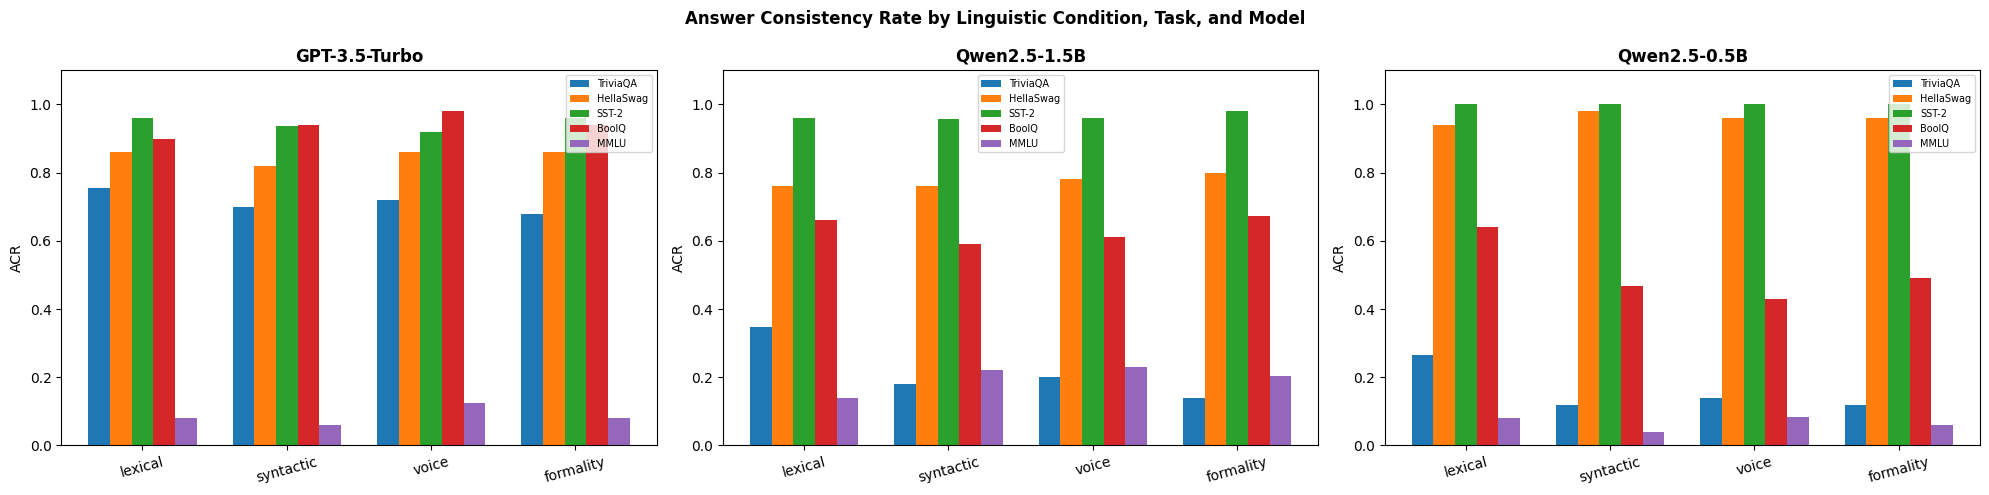

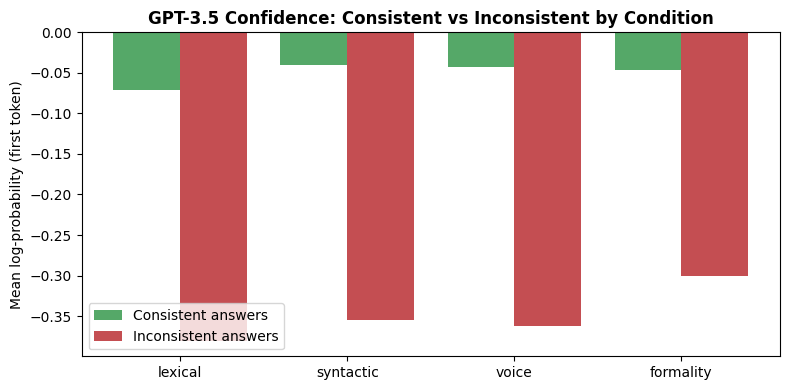

In [35]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ["lexical", "syntactic", "voice", "formality"]
tasks = ["trivia_qa", "hellaswag", "sst2", "boolq", "mmlu"]
task_labels = ["TriviaQA", "HellaSwag", "SST-2", "BoolQ", "MMLU"]
model_names = ["gpt", "llama", "gemma"]
model_labels = ["GPT-3.5-Turbo", "Qwen2.5-1.5B", "Qwen2.5-0.5B"]

# Figure 1: ACR by condition and task, one panel per model
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, model, label in zip(axes, model_names, model_labels):
    model_data = summary[summary["model"] == model]
    x = np.arange(len(conditions))
    width = 0.15
    for i, (task, tlabel) in enumerate(zip(tasks, task_labels)):
        vals = []
        for c in conditions:
            subset = model_data[
                (model_data["task"] == task) &
                (model_data["condition"] == c)
            ]["ACR"].values
            vals.append(subset[0] if len(subset) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=tlabel)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(conditions, rotation=15)
    ax.set_ylim(0, 1.1)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("ACR")
    ax.legend(fontsize=7)

plt.suptitle("Answer Consistency Rate by Linguistic Condition, Task, and Model",
             fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_acr.pdf", bbox_inches="tight")
plt.show()

# Figure 2: GPT-3.5 confidence on consistent vs inconsistent responses
fig2, ax2 = plt.subplots(figsize=(8, 4))
consistent_vals = []
inconsistent_vals = []

for c in conditions:
    subset = df_results[df_results["condition"] == c]
    consistent_vals.append(
        subset[subset["gpt_consistent"]]["gpt_para_logprob"].mean())
    inconsistent_vals.append(
        subset[~subset["gpt_consistent"]]["gpt_para_logprob"].mean())

x = np.arange(len(conditions))
ax2.bar(x - 0.2, consistent_vals, 0.4,
        label="Consistent answers", color="#55A868")
ax2.bar(x + 0.2, inconsistent_vals, 0.4,
        label="Inconsistent answers", color="#C44E52")
ax2.set_xticks(x)
ax2.set_xticklabels(conditions)
ax2.set_ylabel("Mean log-probability (first token)")
ax2.set_title("GPT-3.5 Confidence: Consistent vs Inconsistent by Condition",
              fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.savefig("fig2_confidence.pdf", bbox_inches="tight")
plt.show()

## 16. Error Analysis
Identifies cases where the paraphrase flipped a correct answer to
a wrong one. Breaks down flip counts by model, task, and condition
to show which linguistic feature causes the most harmful
inconsistencies. Includes sample examples showing the original
question, paraphrase, gold answer, and model outputs for each flip.

In [37]:
df_results_full = df_results.merge(
    df_clean[["task", "instance_id", "condition", "original", "paraphrase"]],
    on=["task", "instance_id", "condition"],
    how="left"
)

for model_prefix in ["gpt", "llama", "gemma"]:
    model_label = {
        "gpt": "GPT-3.5-Turbo",
        "llama": "Qwen2.5-1.5B",
        "gemma": "Qwen2.5-0.5B"
    }[model_prefix]

    flips = df_results_full[
        (df_results_full[f"{model_prefix}_orig_correct"]) &
        (~df_results_full[f"{model_prefix}_para_correct"])
    ]
    print(f"\n{model_label} flipped correct to wrong: {len(flips)}")
    print(flips.groupby(["task", "condition"]).size()
          .reset_index(name="count").to_string(index=False))

    print(f"\nSample flip cases for {model_label}:")
    for _, row in flips.head(3).iterrows():
        print(f"\n  Task: {row['task']} | Condition: {row['condition']}")
        print(f"  Original:   {row['original'][:80]}")
        print(f"  Paraphrase: {row['paraphrase'][:80]}")
        print(f"  Gold:       {row['gold_answer']}")
        print(f"  Original answer:   {row[f'{model_prefix}_orig_answer']}")
        print(f"  Paraphrase answer: {row[f'{model_prefix}_para_answer']}")


GPT-3.5-Turbo flipped correct to wrong: 54
     task condition  count
    boolq formality      2
    boolq   lexical      4
    boolq syntactic      2
hellaswag formality      3
hellaswag   lexical      4
hellaswag syntactic      5
hellaswag     voice      5
     mmlu   lexical      2
     mmlu syntactic      3
     mmlu     voice      3
     sst2 formality      1
     sst2 syntactic      2
     sst2     voice      1
trivia_qa formality      4
trivia_qa   lexical      4
trivia_qa syntactic      5
trivia_qa     voice      4

Sample flip cases for GPT-3.5-Turbo:

  Task: trivia_qa | Condition: lexical
  Original:   Which US gangster was released from Alcatraz prison in November 1939?
  Paraphrase: Which American criminal was freed from Alcatraz penitentiary in November 1939?
  Gold:       Al Capone
  Original answer:   Al Capone
  Paraphrase answer: Roy Gardner

  Task: trivia_qa | Condition: formality
  Original:   Which US gangster was released from Alcatraz prison in November 1939?
 